# Mélange par transpositions aléatoires — Phénomène de cutoff

**Mines Nancy — Projet Dep IM 2A 2025-2026**  
Implémentation numérique du théorème de Diaconis-Shahshahani (1981)

---

## Rappel théorique

Le **mélange par transpositions aléatoires** consiste, à chaque étape, à choisir deux positions $i, j$ uniformément dans $\{1,\ldots,N\}^2$ et à échanger les cartes en ces positions. Le noyau de transition est :
$$
Q(\sigma, \sigma') = \begin{cases} 1/N & \text{si } \sigma' = \sigma, \\ 2/N^2 & \text{si } \sigma' = (i\,j)\circ\sigma \text{ pour } i < j. \end{cases}
$$

**Théorème (Diaconis-Shahshahani, 1981).** Ce mélange exhibe un cutoff en variation totale au temps $t_N^* = \frac{N \ln N}{2}$.

La preuve repose sur le **lemme de Diaconis-Shahshahani** :
$$
d(t)^2 \leq \frac{1}{4} \sum_{\rho \neq \text{triv}} d_\rho^2 \, |\lambda_\rho|^{2t},
$$
où, pour la représentation standard $\rho_{\text{std}}$ (dimension $N-1$) :
$$
\lambda_{\text{std}} = \frac{N-2}{N}, \quad \Rightarrow \quad
d(t) \lesssim \frac{N-1}{2}\left(\frac{N-2}{N}\right)^{t}.
$$

**Stratégie de simulation** : on utilise une borne supérieure analytique et une borne inférieure estimée via les points fixes (cartes non touchées).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import poisson
from scipy.special import factorial
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'figure.dpi': 120,
})

SEED = 2025
rng = np.random.default_rng(SEED)
print('Librairies chargées. Graine aléatoire :', SEED)

Librairies chargées. Graine aléatoire : 2025


---
## 1. Simulation naïve du mélange (petits $N$)

On commence par la simulation directe pour se convaincre de la dynamique. On représente l'état du paquet par un tableau NumPy de taille $N$, où `deck[i]` est l'étiquette de la carte à la position $i$.

In [ ]:
def transposition_shuffle_step(deck: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Effectue une étape du mélange par transpositions aléatoires.
    
    Choisit (i, j) uniformément dans {0,...,N-1}^2 et échange deck[i] et deck[j].
    Si i == j, rien ne change.
    
    Paramètres
    ----------
    deck : np.ndarray, shape (N,)
        État courant du paquet (permutation de [0, N-1]).
    rng : np.random.Generator
        Générateur de nombres aléatoires.
    
    Returns
    -------
    np.ndarray
        Nouvel état après une transposition aléatoire.
    """
    N = len(deck)
    i, j = rng.integers(0, N, size=2)
    new_deck = deck.copy()
    new_deck[i], new_deck[j] = new_deck[j], new_deck[i]
    return new_deck


def count_fixed_points(deck: np.ndarray) -> int:
    """Compte le nombre de points fixes de la permutation.
    
    La carte à la position i est un point fixe si deck[i] == i.
    """
    return int(np.sum(deck == np.arange(len(deck))))


def simulate_chain_fixed_points(
    N: int, t_max: int, n_simulations: int, rng: np.random.Generator
) -> np.ndarray:
    """Simule n_simulations réalisations de la chaîne et retourne
    le nombre de points fixes à chaque temps t = 0, ..., t_max.
    
    Returns
    -------
    fixed_pts : np.ndarray, shape (n_simulations, t_max+1)
        fixed_pts[k, t] = nombre de points fixes au temps t, simulation k.
    """
    initial_deck = np.arange(N)
    fixed_pts = np.zeros((n_simulations, t_max + 1), dtype=np.int32)
    
    for k in range(n_simulations):
        deck = initial_deck.copy()
        fixed_pts[k, 0] = count_fixed_points(deck)
        for t in range(1, t_max + 1):
            deck = transposition_shuffle_step(deck, rng)
            fixed_pts[k, t] = count_fixed_points(deck)
    
    return fixed_pts

print('Fonctions de simulation définies.')

Fonctions de simulation définies.


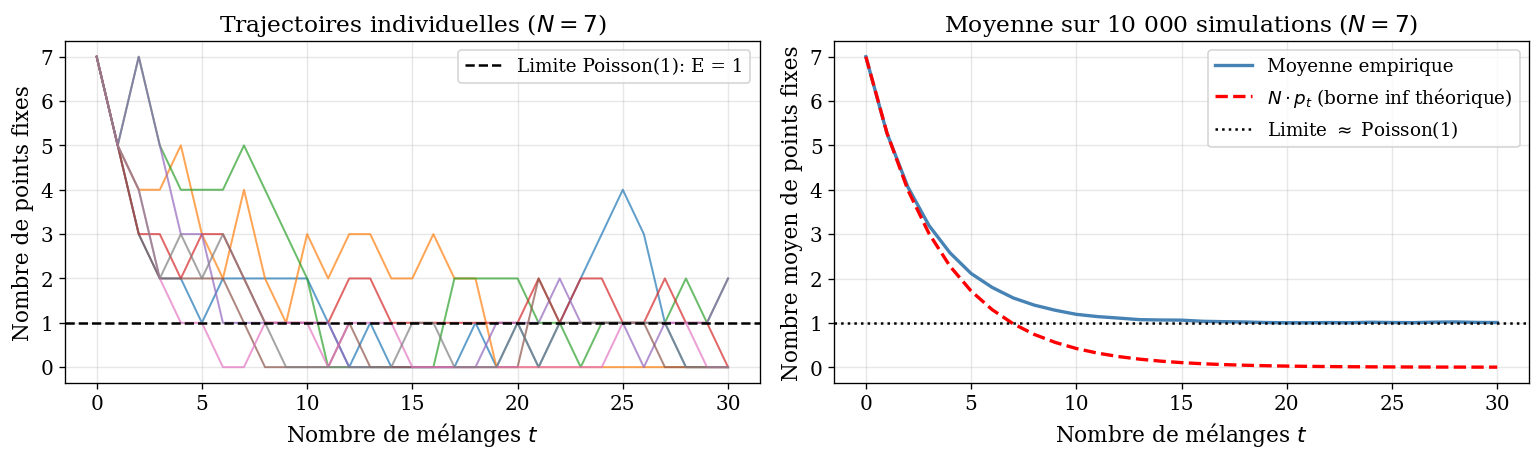

Figure sauvegardée.


In [3]:
# Démonstration : évolution des points fixes pour N=7, quelques trajectoires
N_demo = 7
t_max_demo = 30
n_traj = 8

rng_demo = np.random.default_rng(42)
fixed_pts_demo = simulate_chain_fixed_points(N_demo, t_max_demo, n_traj, rng_demo)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Trajectoires individuelles
ax = axes[0]
t_range = np.arange(t_max_demo + 1)
for k in range(n_traj):
    ax.plot(t_range, fixed_pts_demo[k], alpha=0.7, linewidth=1.2)
ax.axhline(1, color='k', linestyle='--', linewidth=1.5, label='Limite Poisson(1): E = 1')
ax.set_xlabel('Nombre de mélanges $t$')
ax.set_ylabel('Nombre de points fixes')
ax.set_title(f'Trajectoires individuelles ($N={N_demo}$)')
ax.legend()
ax.grid(True, alpha=0.3)

# Moyenne sur 10000 simulations
rng_avg = np.random.default_rng(SEED)
fixed_pts_avg = simulate_chain_fixed_points(N_demo, t_max_demo, 10000, rng_avg)
mean_fp = fixed_pts_avg.mean(axis=0)

ax = axes[1]
ax.plot(t_range, mean_fp, color='steelblue', linewidth=2, label='Moyenne empirique')
# Courbe théorique: E[nb non touchées] + 0 (cartes touchées peuvent aussi être fixes)
p_t = (1 - 2*(N_demo-1)/N_demo**2)**np.arange(t_max_demo+1)
ax.plot(t_range, N_demo * p_t, 'r--', linewidth=2, label=r'$N \cdot p_t$ (borne inf théorique)')
ax.axhline(1, color='k', linestyle=':', linewidth=1.5, label='Limite $\\approx$ Poisson(1)')
ax.set_xlabel('Nombre de mélanges $t$')
ax.set_ylabel('Nombre moyen de points fixes')
ax.set_title(f'Moyenne sur 10 000 simulations ($N={N_demo}$)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_points_fixes.pdf', bbox_inches='tight')
plt.show()
print('Figure sauvegardée.')

---
## 2. Borne supérieure analytique

D'après le lemme de Diaconis-Shahshahani, la borne supérieure est donnée par :
$$
d(t)^2 \leq \frac{1}{4} \sum_{\rho \neq \text{triv}} d_\rho^2 \left|\lambda_\rho\right|^{2t}
\approx \frac{(N-1)^2}{4} \left(\frac{N-2}{N}\right)^{2t}
$$
en ne gardant que le terme dominant (représentation standard).

In [4]:
def upper_bound_std(N: int, t: np.ndarray) -> np.ndarray:
    """Borne supérieure sur d(t) via la représentation standard.
    
    d(t) <= sqrt(d_std^2 * lambda_std^{2t} / 4)
    
    Avec d_std = N-1 et lambda_std = (N-2)/N.
    
    Parameters
    ----------
    N : int
        Nombre de cartes.
    t : np.ndarray
        Tableau des temps.
    
    Returns
    -------
    np.ndarray
        Borne supérieure sur d(t).
    """
    d_std = N - 1
    lambda_std = (N - 2) / N
    # On clippe à 1 pour avoir une borne valide (d(t) <= 1 toujours)
    return np.minimum(1.0, 0.5 * d_std * lambda_std**t)


def upper_bound_full(N: int, t: np.ndarray) -> np.ndarray:
    """Borne supérieure incluant les représentations triviale, signe et standard.
    
    On inclut ici la représentation signe (dimension 1, lambda = -(N-2)/N)
    en plus de la représentation standard.
    """
    # Représentation standard : d=N-1, lambda=(N-2)/N
    contrib_std = (N-1)**2 * ((N-2)/N)**(2*t)
    # Représentation signe : d=1, |lambda|=(N-2)/N
    contrib_sgn = 1.0 * ((N-2)/N)**(2*t)
    d2_squared = contrib_std + contrib_sgn
    return np.minimum(1.0, 0.5 * np.sqrt(d2_squared))


# Vérification : comportement en t = N ln(N) / 2
for N in [10, 52, 100, 200]:
    t_star = N * np.log(N) / 2
    ub = upper_bound_std(N, t_star)
    print(f'N={N:4d}, t* = {t_star:.1f}, borne sup d(t*) ≈ {ub:.4f}')

N=  10, t* = 11.5, borne sup d(t*) ≈ 0.3447
N=  52, t* = 102.7, borne sup d(t*) ≈ 0.4536
N= 100, t* = 230.3, borne sup d(t*) ≈ 0.4724
N= 200, t* = 529.8, borne sup d(t*) ≈ 0.4844


---
## 3. Borne inférieure par Monte-Carlo

On estime $d(t)$ depuis le bas via les **cartes non touchées** :
$$
d(t) \geq P(X_t \in A_K) - \pi(A_K),
$$
où $A_K = \{\sigma : \#\text{points fixes}(\sigma) \geq K\}$.

**Astuce clé** : on ne simule pas la permutation entière. On suit seulement si chaque carte a été touchée, ce qui est beaucoup plus efficace.

In [5]:
def simulate_untouched_fraction(
    N: int,
    t_values: np.ndarray,
    n_simulations: int,
    rng: np.random.Generator
) -> np.ndarray:
    """Estime P(nb cartes non touchées >= K=1) = P(>=1 carte non touchée) pour chaque t.
    
    Plus précisément, retourne le nombre moyen de cartes non touchées en fonction de t.
    Ceci minore le nombre de points fixes.
    
    Strategy: pour chaque simulation, on tire n_steps transpositions et on suit
    un tableau binaire `touched` de taille N.
    
    Parameters
    ----------
    N : int
        Nombre de cartes.
    t_values : np.ndarray
        Temps auxquels on veut l'estimation (triés croissants).
    n_simulations : int
        Nombre de simulations Monte-Carlo.
    rng : np.random.Generator
        Générateur de nombres aléatoires.
    
    Returns
    -------
    mean_untouched : np.ndarray, shape (len(t_values),)
        Nombre moyen de cartes non touchées à chaque t.
    """
    t_max = int(t_values[-1])
    t_sorted = np.sort(t_values).astype(int)
    
    # Génère toutes les transpositions d'un coup pour efficacité
    # Shape : (n_simulations, t_max, 2)
    all_pairs = rng.integers(0, N, size=(n_simulations, t_max, 2))
    
    # touched[k, i] = True si la carte i a été touchée dans la simu k
    touched = np.zeros((n_simulations, N), dtype=bool)
    
    mean_untouched = np.zeros(len(t_sorted))
    t_idx = 0
    
    for step in range(t_max):
        pairs = all_pairs[:, step, :]  # shape (n_simulations, 2)
        i_arr = pairs[:, 0]
        j_arr = pairs[:, 1]
        # Marquer les cartes touchées (si i != j)
        non_trivial = i_arr != j_arr
        touched[non_trivial, i_arr[non_trivial]] = True
        touched[non_trivial, j_arr[non_trivial]] = True
        
        current_t = step + 1
        while t_idx < len(t_sorted) and t_sorted[t_idx] == current_t:
            # Nombre de cartes non touchées pour chaque simulation
            untouched_count = np.sum(~touched, axis=1)  # shape (n_simulations,)
            mean_untouched[t_idx] = untouched_count.mean()
            t_idx += 1
    
    return mean_untouched


def lower_bound_mc(
    N: int,
    t_values: np.ndarray,
    n_simulations: int,
    K: int,
    rng: np.random.Generator
) -> np.ndarray:
    """Borne inférieure sur d(t) via les cartes non touchées.
    
    d(t) >= P(nb non touchées >= K) - pi(A_K)
    
    où pi(A_K) = P(Poisson(1) >= K) pour N grand.
    
    Parameters
    ----------
    N, t_values, n_simulations : voir simulate_untouched_fraction.
    K : int
        Seuil (prendre K=1 pour la borne la plus simple).
    rng : générateur.
    
    Returns
    -------
    lower_bound : np.ndarray, shape (len(t_values),)
    """
    t_max = int(t_values[-1])
    t_sorted = np.sort(t_values).astype(int)
    
    all_pairs = rng.integers(0, N, size=(n_simulations, t_max, 2))
    touched = np.zeros((n_simulations, N), dtype=bool)
    
    lb = np.zeros(len(t_sorted))
    # pi(A_K) = P(Poisson(1) >= K)
    pi_AK = 1 - poisson.cdf(K - 1, mu=1.0)
    
    t_idx = 0
    for step in range(t_max):
        pairs = all_pairs[:, step, :]
        i_arr, j_arr = pairs[:, 0], pairs[:, 1]
        non_trivial = i_arr != j_arr
        touched[non_trivial, i_arr[non_trivial]] = True
        touched[non_trivial, j_arr[non_trivial]] = True
        
        current_t = step + 1
        while t_idx < len(t_sorted) and t_sorted[t_idx] == current_t:
            untouched_count = np.sum(~touched, axis=1)
            # P(nb non touchées >= K)
            prob_AK = np.mean(untouched_count >= K)
            lb[t_idx] = max(0.0, prob_AK - pi_AK)
            t_idx += 1
    
    return lb

print('Fonctions de borne inférieure définies.')

Fonctions de borne inférieure définies.


---
## 4. Phénomène de cutoff pour $N = 52$ cartes

Comparaison borne supérieure analytique / borne inférieure Monte-Carlo, pour un jeu de 52 cartes.

N = 52, seuil théorique t* = 102.73
Simulation de 50,000 trajectoires sur 308 pas...
Calcul terminé.


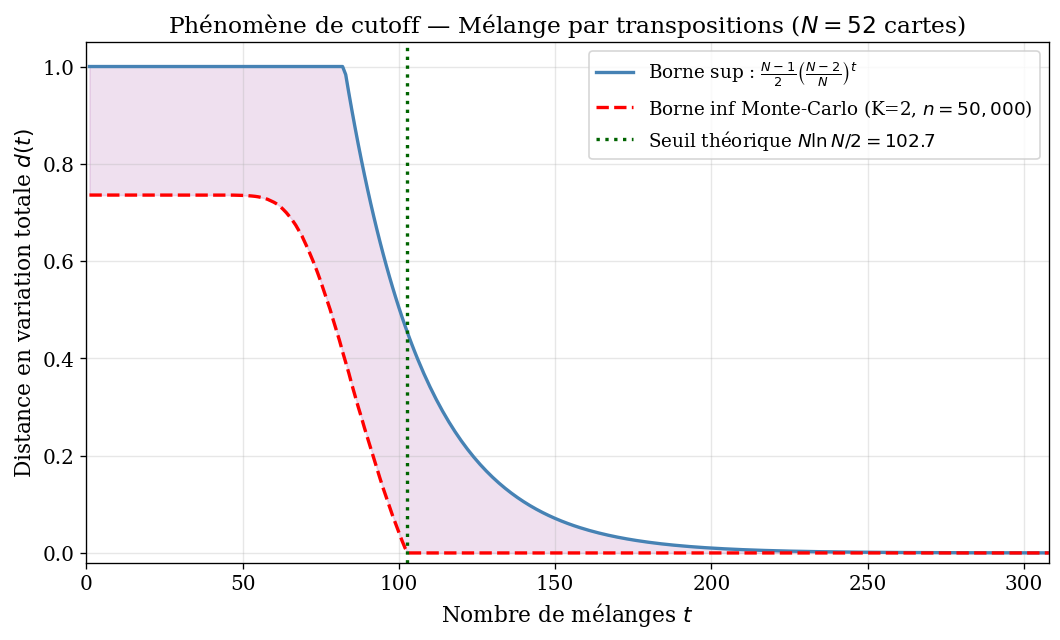

In [6]:
N = 52
t_star = N * np.log(N) / 2
t_max = int(3.0 * t_star)
n_sim = 50_000
K = 2  # Seuil pour la borne inférieure

print(f'N = {N}, seuil théorique t* = {t_star:.2f}')
print(f'Simulation de {n_sim:,} trajectoires sur {t_max} pas...')

# Temps auxquels on évalue
t_eval = np.arange(1, t_max + 1)

# Borne supérieure (analytique)
ub = upper_bound_std(N, t_eval)

# Borne inférieure (Monte-Carlo)
rng_52 = np.random.default_rng(SEED)
lb = lower_bound_mc(N, t_eval, n_sim, K, rng_52)

print('Calcul terminé.')

# Visualisation
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(t_eval, ub, color='steelblue', linewidth=2.0,
        label=r'Borne sup : $\frac{N-1}{2}\left(\frac{N-2}{N}\right)^t$')
ax.plot(t_eval, lb, 'r--', linewidth=2.0,
        label=f'Borne inf Monte-Carlo (K={K}, $n={n_sim:,}$)')
ax.axvline(t_star, color='darkgreen', linestyle=':', linewidth=2.0,
           label=f'Seuil théorique $N\\ln N/2 = {t_star:.1f}$')

ax.set_xlabel('Nombre de mélanges $t$')
ax.set_ylabel('Distance en variation totale $d(t)$')
ax.set_title(f'Phénomène de cutoff — Mélange par transpositions ($N={N}$ cartes)')
ax.set_xlim(0, t_max)
ax.set_ylim(-0.02, 1.05)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.fill_between(t_eval, lb, ub, alpha=0.12, color='purple', label='Zone encadrement')

plt.tight_layout()
plt.savefig('fig_transp_N52.pdf', bbox_inches='tight')
plt.show()

---
## 5. Phénomène de cutoff pour $N = 200$ cartes

Pour un $N$ plus grand, le cutoff est beaucoup plus abrupt, conformément à la définition.

N = 200, seuil théorique t* = 529.83
Simulation de 30,000 trajectoires sur 1324 pas...
Calcul terminé.


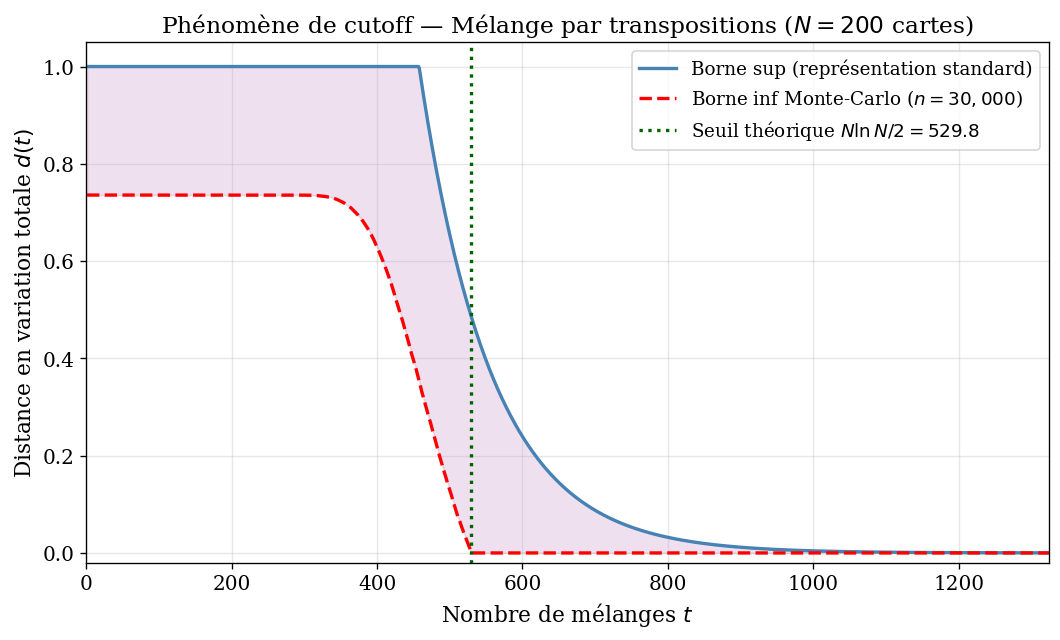

In [7]:
N2 = 200
t_star2 = N2 * np.log(N2) / 2
t_max2 = int(2.5 * t_star2)
n_sim2 = 30_000

print(f'N = {N2}, seuil théorique t* = {t_star2:.2f}')
print(f'Simulation de {n_sim2:,} trajectoires sur {t_max2} pas...')

t_eval2 = np.arange(1, t_max2 + 1)
ub2 = upper_bound_std(N2, t_eval2)

rng_200 = np.random.default_rng(SEED + 1)
lb2 = lower_bound_mc(N2, t_eval2, n_sim2, K, rng_200)
print('Calcul terminé.')

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(t_eval2, ub2, color='steelblue', linewidth=2.0,
        label=r'Borne sup (représentation standard)')
ax.plot(t_eval2, lb2, 'r--', linewidth=2.0,
        label=f'Borne inf Monte-Carlo ($n={n_sim2:,}$)')
ax.axvline(t_star2, color='darkgreen', linestyle=':', linewidth=2.0,
           label=f'Seuil théorique $N\\ln N/2 = {t_star2:.1f}$')
ax.fill_between(t_eval2, lb2, ub2, alpha=0.12, color='purple')

ax.set_xlabel('Nombre de mélanges $t$')
ax.set_ylabel('Distance en variation totale $d(t)$')
ax.set_title(f'Phénomène de cutoff — Mélange par transpositions ($N={N2}$ cartes)')
ax.set_xlim(0, t_max2)
ax.set_ylim(-0.02, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_transp_N200.pdf', bbox_inches='tight')
plt.show()

---
## 6. Comparaison avec le Top-in-at-random

On compare les seuils de cutoff des deux mélanges en traçant les bornes supérieures normalisées par le seuil théorique de chaque mélange.

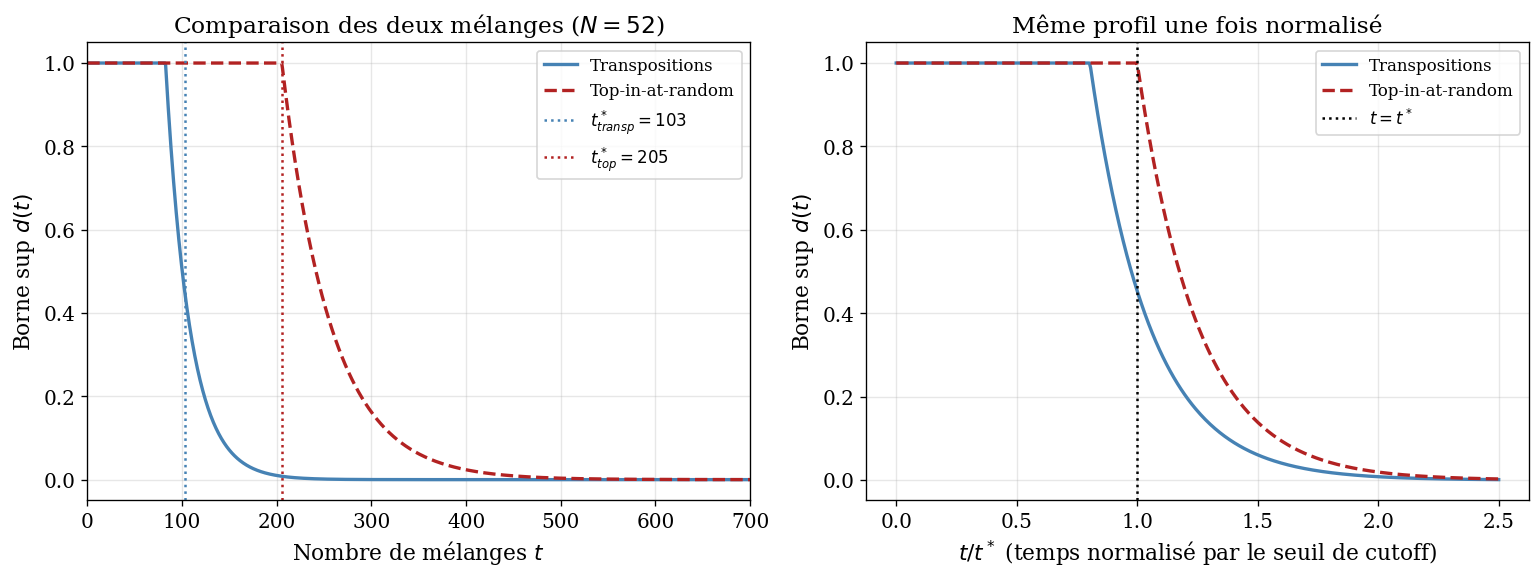

Seuil transpositions : N ln(N)/2 = 102.73
Seuil top-in-at-random : N ln(N) = 205.46
Rapport : 2.0x


In [8]:
def upper_bound_top_in_at_random(N: int, t: np.ndarray) -> np.ndarray:
    """Borne supérieure pour le top-in-at-random : P(T > t) <= N*exp(-t/N)."""
    return np.minimum(1.0, N * np.exp(-t / N))


N_comp = 52
t_star_transp = N_comp * np.log(N_comp) / 2   # ~205
t_star_top    = N_comp * np.log(N_comp)         # ~410

# On trace en fonction de t / t_star pour chaque mélange
alpha_values = np.linspace(0, 2.5, 500)  # t = alpha * t_star

# Borne sup transpositions (normalisée par t_star_transp)
t_transp = alpha_values * t_star_transp
ub_transp_norm = upper_bound_std(N_comp, t_transp)

# Borne sup top-in-at-random (normalisée par t_star_top)
t_top = alpha_values * t_star_top
ub_top_norm = upper_bound_top_in_at_random(N_comp, t_top)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panneau gauche : échelle de temps absolue
ax = axes[0]
t_abs = np.linspace(0, 700, 1000)
ax.plot(t_abs, upper_bound_std(N_comp, t_abs),
        color='steelblue', lw=2, label='Transpositions')
ax.plot(t_abs, upper_bound_top_in_at_random(N_comp, t_abs),
        color='firebrick', lw=2, linestyle='--', label='Top-in-at-random')
ax.axvline(t_star_transp, color='steelblue', linestyle=':', lw=1.5,
           label=f'$t^*_{{transp}} = {t_star_transp:.0f}$')
ax.axvline(t_star_top, color='firebrick', linestyle=':', lw=1.5,
           label=f'$t^*_{{top}} = {t_star_top:.0f}$')
ax.set_xlabel('Nombre de mélanges $t$')
ax.set_ylabel('Borne sup $d(t)$')
ax.set_title(f'Comparaison des deux mélanges ($N={N_comp}$)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 700)

# Panneau droit : temps normalisé par t_star
ax = axes[1]
ax.plot(alpha_values, ub_transp_norm, color='steelblue', lw=2, label='Transpositions')
ax.plot(alpha_values, ub_top_norm, color='firebrick', lw=2, linestyle='--',
        label='Top-in-at-random')
ax.axvline(1.0, color='k', linestyle=':', lw=1.5, label='$t = t^*$')
ax.set_xlabel('$t / t^*$ (temps normalisé par le seuil de cutoff)')
ax.set_ylabel('Borne sup $d(t)$')
ax.set_title('Même profil une fois normalisé')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_comparaison_melanges.pdf', bbox_inches='tight')
plt.show()
print(f"Seuil transpositions : N ln(N)/2 = {t_star_transp:.2f}")
print(f"Seuil top-in-at-random : N ln(N) = {t_star_top:.2f}")
print(f"Rapport : {t_star_top/t_star_transp:.1f}x")

---
## 7. Vérification du cutoff : rapport des temps de mélange

Par définition, il y a cutoff si et seulement si $t_{\mathrm{mix}}^{(N)}(\varepsilon) / t_{\mathrm{mix}}^{(N)}(1-\varepsilon) \to 1$ pour tout $\varepsilon \in (0,1)$.  
On vérifie ce rapport numériquement en utilisant la borne supérieure analytique.

In [9]:
def mixing_time_from_upper_bound(N: int, epsilon: float) -> float:
    """Estime t_mix(epsilon) via la borne supérieure d(t) <= UB(t).
    
    On trouve le plus petit t tel que UB(t) <= epsilon.
    """
    t_max_search = int(10 * N * np.log(N))
    t_arr = np.arange(1, t_max_search)
    ub = upper_bound_std(N, t_arr)
    idx = np.where(ub <= epsilon)[0]
    if len(idx) == 0:
        return np.inf
    return float(t_arr[idx[0]])


# Ratio t_mix(eps) / t_mix(1-eps) pour différentes valeurs de N et eps
N_values = [10, 20, 50, 100, 200, 500]
epsilon_values = [0.25, 0.1, 0.05]

print('N      | ε=0.25         | ε=0.10         | ε=0.05')
print('       | t(ε)/t(1-ε)    | t(ε)/t(1-ε)    | t(ε)/t(1-ε)')
print('-' * 65)

ratios_data = {}
for N_val in N_values:
    row = []
    for eps in epsilon_values:
        t_eps = mixing_time_from_upper_bound(N_val, eps)
        t_1meps = mixing_time_from_upper_bound(N_val, 1 - eps)
        ratio = t_eps / t_1meps if t_1meps > 0 else np.inf
        row.append(ratio)
    ratios_data[N_val] = row
    print(f'N={N_val:4d} | {row[0]:10.4f}       | {row[1]:10.4f}       | {row[2]:10.4f}')

print('\nRemarque : le rapport → 1 quand N → ∞, confirmant le cutoff.')

N      | ε=0.25         | ε=0.10         | ε=0.05
       | t(ε)/t(1-ε)    | t(ε)/t(1-ε)    | t(ε)/t(1-ε)
-----------------------------------------------------------------
N=  10 |     1.4444       |     2.2500       |     3.0000
N=  20 |     1.4000       |     1.9130       |     2.2727
N=  50 |     1.3140       |     1.6667       |     1.9000
N= 100 |     1.2596       |     1.5477       |     1.7449
N= 200 |     1.2238       |     1.4648       |     1.6328
N= 500 |     1.1891       |     1.3903       |     1.5288

Remarque : le rapport → 1 quand N → ∞, confirmant le cutoff.


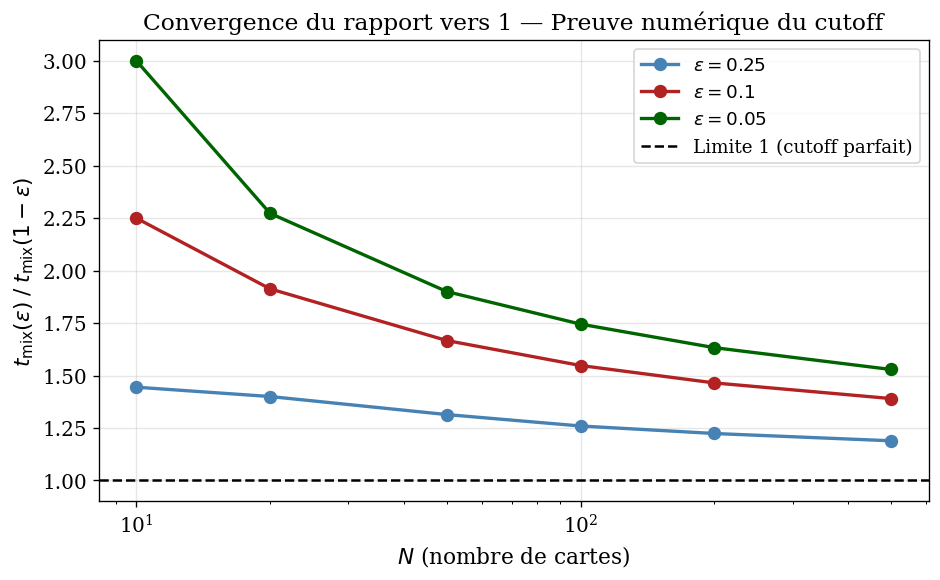

In [10]:
# Graphe du rapport t_mix(eps)/t_mix(1-eps) en fonction de N
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['steelblue', 'firebrick', 'darkgreen']
for k, eps in enumerate(epsilon_values):
    ratios = [ratios_data[N_val][k] for N_val in N_values]
    ax.plot(N_values, ratios, 'o-', color=colors[k], linewidth=2,
            markersize=7, label=f'$\\varepsilon = {eps}$')

ax.axhline(1.0, color='k', linestyle='--', linewidth=1.5, label='Limite 1 (cutoff parfait)')
ax.set_xlabel('$N$ (nombre de cartes)')
ax.set_ylabel(r'$t_{\mathrm{mix}}(\varepsilon)\;/\;t_{\mathrm{mix}}(1-\varepsilon)$')
ax.set_title('Convergence du rapport vers 1 — Preuve numérique du cutoff')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.savefig('fig_ratio_cutoff.pdf', bbox_inches='tight')
plt.show()

---
## 8. Visualisation des valeurs propres $\lambda_\rho$

On représente les valeurs propres des principales représentations en fonction de $N$,
et leur contribution à la borne supérieure.
On voit clairement que $\lambda_{\text{std}} = (N-2)/N$ est la plus proche de $1$,
et domine donc l'asymptotique.

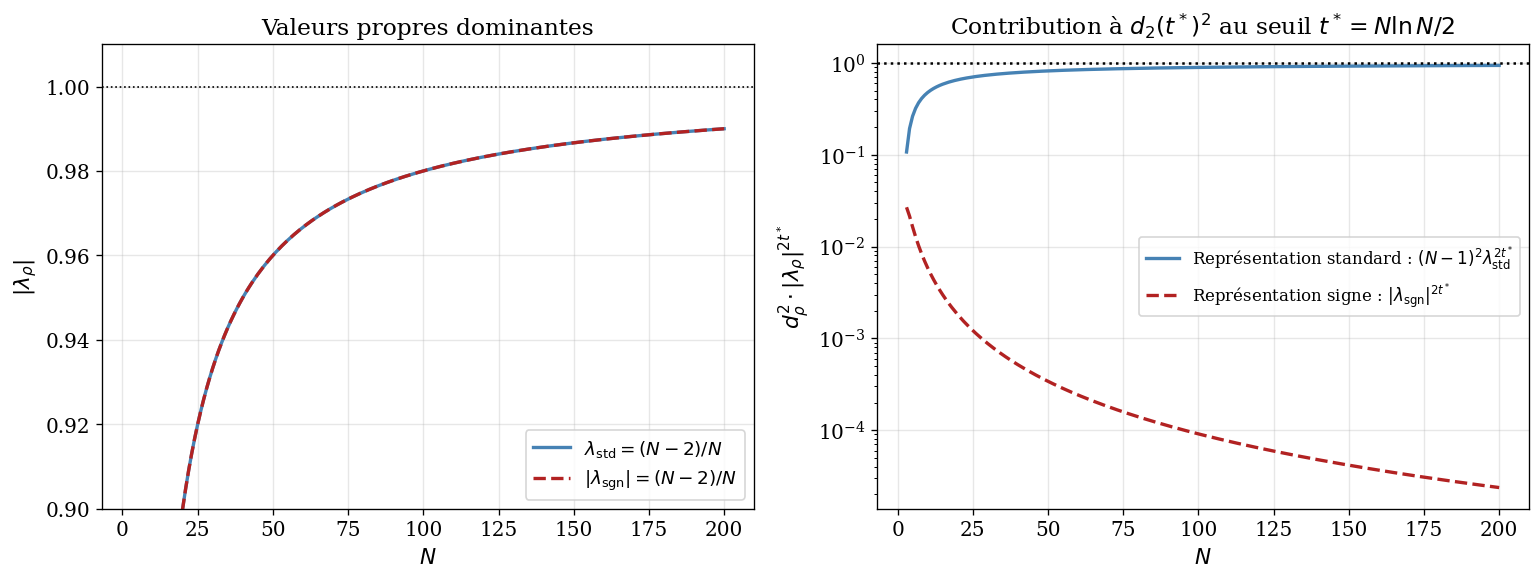

Contribution de rho_std à t = t_star pour N=52 : 0.8229829859051364
Contribution de rho_sgn à t = t_star pour N=52 : 0.0003164102214168152


In [11]:
N_range = np.arange(3, 201)

lambda_std = (N_range - 2) / N_range          # (N-2)/N
lambda_sgn = -(N_range - 2) / N_range         # -(N-2)/N

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(N_range, lambda_std, color='steelblue', lw=2, label=r'$\lambda_{\mathrm{std}} = (N-2)/N$')
ax.plot(N_range, np.abs(lambda_sgn), color='firebrick', lw=2, linestyle='--',
        label=r'$|\lambda_{\mathrm{sgn}}| = (N-2)/N$')
ax.axhline(1, color='k', linestyle=':', lw=1)
ax.set_xlabel('$N$')
ax.set_ylabel(r'$|\lambda_\rho|$')
ax.set_title('Valeurs propres dominantes')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.9, 1.01)

# Panneau droit : contribution (d_rho^2 * lambda_rho^{2*t*}) à t = t*
ax = axes[1]
t_star_N = N_range * np.log(N_range) / 2
contrib_std = (N_range - 1)**2 * lambda_std**(2 * t_star_N)
contrib_sgn = 1.0 * (N_range - 2)**2 / N_range**2  # |lambda_sgn|^{2t*}
contrib_sgn = 1.0 * np.abs(lambda_sgn)**(2 * t_star_N)

ax.semilogy(N_range, contrib_std, color='steelblue', lw=2,
            label=r'Représentation standard : $(N-1)^2 \lambda_{\mathrm{std}}^{2t^*}$')
ax.semilogy(N_range, contrib_sgn, color='firebrick', lw=2, linestyle='--',
            label=r'Représentation signe : $|\lambda_{\mathrm{sgn}}|^{2t^*}$')
ax.axhline(1.0, color='k', linestyle=':', lw=1.5)
ax.set_xlabel('$N$')
ax.set_ylabel(r'$d_\rho^2 \cdot |\lambda_\rho|^{2t^*}$')
ax.set_title(r'Contribution à $d_2(t^*)^2$ au seuil $t^* = N\ln N/2$')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_valeurs_propres.pdf', bbox_inches='tight')
plt.show()

print('Contribution de rho_std à t = t_star pour N=52 :', contrib_std[52-3])
print('Contribution de rho_sgn à t = t_star pour N=52 :', contrib_sgn[52-3])

---
## 9. Récapitulatif : cutoff multi-N

On superpose les courbes de borne supérieure pour plusieurs valeurs de $N$,
normalisées par le seuil théorique $t^* = N\ln N/2$.

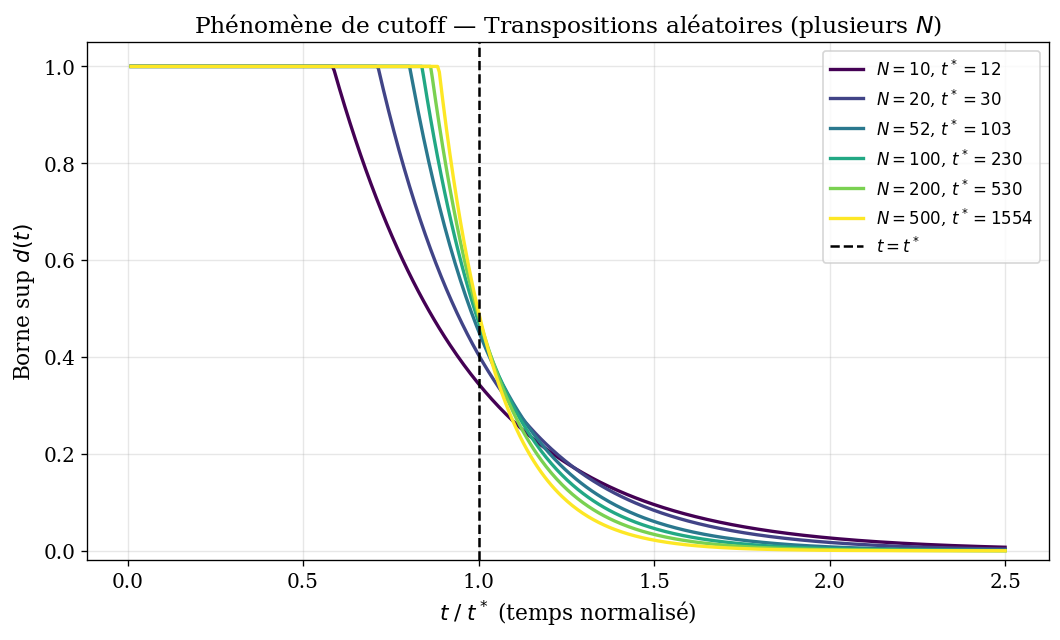

Plus N est grand, plus la transition est abrupte : c'est le phénomène de cutoff.


In [12]:
N_list = [10, 20, 52, 100, 200, 500]
alpha_range = np.linspace(0.01, 2.5, 500)

fig, ax = plt.subplots(figsize=(9, 5.5))

cmap = plt.cm.viridis
colors = [cmap(i / (len(N_list) - 1)) for i in range(len(N_list))]

for i, N_val in enumerate(N_list):
    t_star_val = N_val * np.log(N_val) / 2
    t_vals = alpha_range * t_star_val
    ub_val = upper_bound_std(N_val, t_vals)
    ax.plot(alpha_range, ub_val, color=colors[i], lw=2,
            label=f'$N = {N_val}$, $t^* = {t_star_val:.0f}$')

ax.axvline(1.0, color='k', linestyle='--', lw=1.5, label='$t = t^*$')
ax.set_xlabel(r'$t \;/\; t^*$ (temps normalisé)')
ax.set_ylabel('Borne sup $d(t)$')
ax.set_title('Phénomène de cutoff — Transpositions aléatoires (plusieurs $N$)')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.savefig('fig_cutoff_multi_N.pdf', bbox_inches='tight')
plt.show()

print("Plus N est grand, plus la transition est abrupte : c'est le phénomène de cutoff.")

---
## 10. Récapitulatif des résultats

| Mélange | Seuil de cutoff | Méthode de preuve |
|---|---|---|
| Top-in-at-random | $N \ln N$ | Temps uniforme fort (prob. du collectionneur) |
| Transpositions aléatoires | $\frac{N \ln N}{2}$ | Théorie des représentations (Diaconis-Shahshahani) |

**Messages clés :**
1. Les transpositions mélangent **deux fois plus vite** car elles touchent deux cartes à chaque étape.
2. La **théorie des représentations** est essentielle pour obtenir la constante exacte $1/2$.
3. La borne supérieure est dominée par la **représentation standard** $\rho_{\text{std}}$, de dimension $N-1$.
4. La **borne inférieure** repose sur le comptage des points fixes, qui sont nombreux avant le seuil.

**Formule à retenir** :
$$
d(t)^2 \leq \frac{1}{4} \sum_{\rho \neq \text{triv}} d_\rho^2 \, \left(\frac{1}{N} + \frac{N-1}{N} r(\rho)\right)^{2t},
\quad r(\rho) = \frac{\chi_\rho(\tau)}{d_\rho}.
$$

In [13]:
# Table de synthèse : temps de mélange pour différents N
print('='*65)
print(f'{"N":>5} | {"t* transp":>12} | {"t* top-in":>12} | {"Rapport":>8}')
print('-'*65)
for N_val in [7, 10, 20, 52, 100, 200, 500, 1000]:
    t_transp = N_val * np.log(N_val) / 2
    t_top    = N_val * np.log(N_val)
    print(f'{N_val:>5} | {t_transp:>12.1f} | {t_top:>12.1f} | {t_top/t_transp:>8.1f}')
print('='*65)

    N |    t* transp |    t* top-in |  Rapport
-----------------------------------------------------------------
    7 |          6.8 |         13.6 |      2.0
   10 |         11.5 |         23.0 |      2.0
   20 |         30.0 |         59.9 |      2.0
   52 |        102.7 |        205.5 |      2.0
  100 |        230.3 |        460.5 |      2.0
  200 |        529.8 |       1059.7 |      2.0
  500 |       1553.7 |       3107.3 |      2.0
 1000 |       3453.9 |       6907.8 |      2.0
